<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10 non-null     int64 
 1   income          10 non-null     int64 
 2   job             10 non-null     object
 3   marital_status  10 non-null     object
 4   loan_accepted   10 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 532.0+ bytes


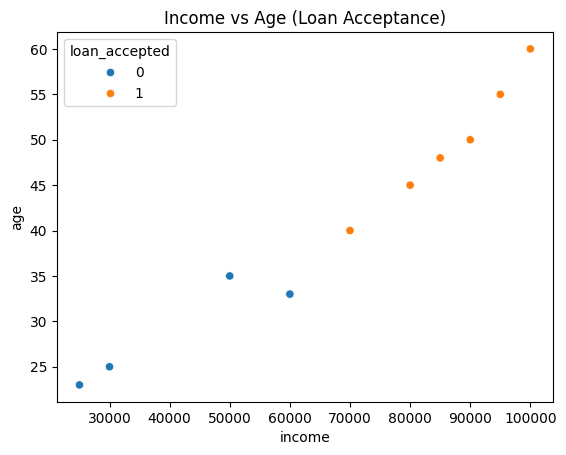

ValueError: Could not interpret value `job_employee` for `x`. An entry with this name does not appear in `data`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
data = {
    'age': [25, 45, 35, 50, 23, 40, 60, 48, 33, 55],
    'income': [30000, 80000, 50000, 90000, 25000, 70000, 100000, 85000, 60000, 95000],
    'job': ['student', 'manager', 'employee', 'manager', 'student', 'employee', 'retired', 'manager', 'employee', 'retired'],
    'marital_status': ['single', 'married', 'single', 'married', 'single', 'married', 'married', 'married', 'single', 'married'],
    'loan_accepted': [0, 1, 0, 1, 0, 1, 1, 1, 0, 1]
}

df = pd.DataFrame(data)
df
df.head()
df.info()
df.describe()
df = pd.get_dummies(df, columns=['job', 'marital_status'], drop_first=True)
df
sns.scatterplot(x='income', y='age', hue='loan_accepted', data=df)
plt.title("Income vs Age (Loan Acceptance)")
plt.show()
sns.countplot(x='job_employee', hue='loan_accepted', data=df)
plt.title("Job vs Loan Acceptance")
plt.show()
X = df.drop('loan_accepted', axis=1)
y = df['loan_accepted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()